<a href="https://colab.research.google.com/github/fox-buddy/MachineLearning-Collection/blob/main/keras_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [61]:
loaded_data = tf.keras.datasets.mnist.load_data()

In [62]:
len(loaded_data[0]) # Two Tuples. First has train data and second holds test data

2

In [63]:
(X_train_full, y_train_full), (X_test, y_test) = loaded_data

In [64]:
X_train_full.shape

(60000, 28, 28)

In [65]:
X_train_full.dtype

dtype('uint8')

In [66]:
# Validation and train data split
X_valid, X_train = X_train_full[54000:], X_train_full[:54000]
y_valid, y_train = y_train_full[54000:], y_train_full[:54000]

X_test = X_test

In [48]:
X_train.shape

(54000, 28, 28)

In [49]:
X_valid.shape

(6000, 28, 28)

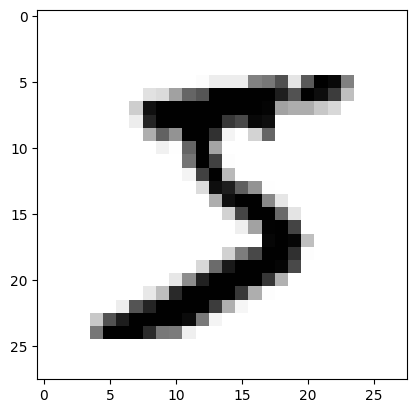

In [50]:
plt.imshow(X_train[0], cmap="binary")
#plt.axis('off')
plt.show()

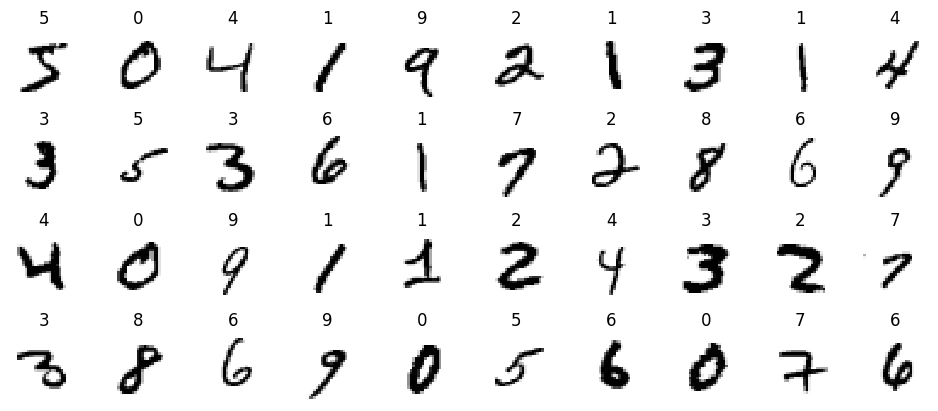

In [67]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [68]:
# Defining optimizer for learning Rate
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])

In [69]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [70]:
model = tf.keras.Sequential()

In [71]:
model.add(tf.keras.layers.Input(shape=[28,28]))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [72]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

optimizer = Adam(learning_rate=3e-1)

In [73]:
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [74]:
# Early Stopping and Checkpoints
from tensorflow.keras.callbacks import EarlyStopping

In [75]:
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)


In [ ]:
history = model.fit(X_train, y_train, epochs=32, validation_data=(X_valid, y_valid), callbacks=[early_stopping_cb, checkpoint_cb])

Epoch 1/32
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.1289 - loss: 877.1332 - val_accuracy: 0.0978 - val_loss: 2.3330
Epoch 2/32
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1010 - loss: 2.3387 - val_accuracy: 0.0978 - val_loss: 2.3351
Epoch 3/32
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.1009 - loss: 2.3389 - val_accuracy: 0.0978 - val_loss: 2.3354
Epoch 4/32
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1009 - loss: 2.3390 - val_accuracy: 0.0978 - val_loss: 2.3355
Epoch 5/32
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.1009 - loss: 2.3390 - val_accuracy: 0.0978 - val_loss: 2.3355
Epoch 6/32
1282/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1014 - loss: 2.3397